# Notebook 07: TOPSIS Multi-Criteria Decision Making (MCDM) Strategy Ranking
**Component 1: AI-Based Business Feasibility Analysis and Personalized Business/Growth Plan Recommendation**

---

## Executive Summary & Research Context
In Phase 6, context-aware alternative business and growth strategies were generated. 
To determine which strategy is optimal for a specific SME, we apply **TOPSIS** (Technique for Order of Preference by Similarity to Ideal Solution), a mathematically defensible Multi-Criteria Decision Making (MCDM) framework.

### Key Objectives:
1. **Decision Matrix Construction**: Represent candidate strategies against 8 financial, operational, and market criteria.
2. **Vector Normalization & Weighted Normalization**: Standardize metrics of varying scales (LKR currency, 1-100 scores, 1-5 ratings) and apply criteria weights.
3. **Ideal & Negative-Ideal Identification**: Identify Positive Ideal Solution ($A^*$) and Negative Ideal Solution ($A^-$) considering explicit Cost vs Benefit criteria classifications.
4. **Euclidean Distance & Closeness Coefficient**: Compute distances ($S_i^*$, $S_i^-$) and relative closeness score ($C_i^* \in [0, 1]$).
5. **Sensitivity Analysis**: Test decision stability under different stakeholder preferences (Balanced vs Capital-Preserving vs Revenue-Maximizing).
6. **Artifact Export**: Export ranked strategies to `models/feasibility_model/topsis_ranked_strategies.json` for Phase 8 (What-If Analysis) & Phase 9 (Personalized Business Plan).


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10

# Directory setup
os.makedirs("../models/feasibility_model", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

print("Setup completed successfully.")


Setup completed successfully.


## 1. Load Strategy Decision Matrix Artifact
Loading generated strategy matrices and criteria definitions exported from Phase 6 (`06_strategy_generation.ipynb`).


In [2]:
artifact_path = "../models/feasibility_model/strategy_matrix_sample.json"

with open(artifact_path, "r", encoding="utf-8") as f:
    strategy_payload = json.load(f)

scenarios = strategy_payload["generated_scenarios"]
criteria_defs = strategy_payload["criteria_definitions"]

print(f"Loaded {len(scenarios)} generated test scenarios.")
print("Criteria Definitions:")
for k, v in criteria_defs.items():
    print(f"  - {k}: {v['label']} (Type: {v['type'].upper()})")


Loaded 3 generated test scenarios.
Criteria Definitions:
  - initial_investment_lkr: Initial Investment (LKR) (Type: COST)
  - monthly_operating_cost_lkr: Monthly Operating Cost (LKR) (Type: COST)
  - expected_monthly_revenue_lkr: Expected Monthly Revenue (LKR) (Type: BENEFIT)
  - market_demand_score: Market Demand Score (1-100) (Type: BENEFIT)
  - competition_mitigation_score: Competition Mitigation Score (1-5) (Type: BENEFIT)
  - resource_availability_score: Resource Availability Score (1-5) (Type: BENEFIT)
  - location_suitability_score: Location Suitability Score (1-5) (Type: BENEFIT)
  - implementation_difficulty: Implementation Difficulty (1-5) (Type: COST)


## 2. Mathematical TOPSIS Engine Implementation
Building the `TOPSISRanker` class implementing the complete mathematical formulation:

1. **Decision Matrix**: $X = [x_{ij}]_{m \times n}$
2. **Vector Normalization**:
   $$r_{ij} = \frac{x_{ij}}{\sqrt{\sum_{k=1}^m x_{kj}^2}}$$
3. **Weighted Normalization**:
   $$v_{ij} = w_j \cdot r_{ij}$$
4. **Ideal Solutions**:
   $$A_j^* = \max_i(v_{ij}) \text{ (Benefit)}, \quad \min_i(v_{ij}) \text{ (Cost)}$$
   $$A_j^- = \min_i(v_{ij}) \text{ (Benefit)}, \quad \max_i(v_{ij}) \text{ (Cost)}$$
5. **Euclidean Distances**:
   $$S_i^* = \sqrt{\sum_{j=1}^n (v_{ij} - A_j^*)^2}, \quad S_i^- = \sqrt{\sum_{j=1}^n (v_{ij} - A_j^-)^2}$$
6. **Relative Closeness Coefficient**:
   $$C_i^* = \frac{S_i^-}{S_i^* + S_i^-}$$


In [3]:
class TOPSISRanker:
    def __init__(self, criteria_definitions):
        self.criteria_defs = criteria_definitions
        self.criteria_keys = list(criteria_definitions.keys())
        self.criteria_types = [criteria_definitions[k]["type"] for k in self.criteria_keys]
        
    def rank_strategies(self, candidate_strategies, weights=None):
        m = len(candidate_strategies)
        n = len(self.criteria_keys)
        
        # Default balanced weights if not provided
        if weights is None:
            weights = {
                "initial_investment_lkr": 0.20,
                "monthly_operating_cost_lkr": 0.15,
                "expected_monthly_revenue_lkr": 0.20,
                "market_demand_score": 0.15,
                "competition_mitigation_score": 0.10,
                "resource_availability_score": 0.05,
                "location_suitability_score": 0.05,
                "implementation_difficulty": 0.10
            }
            
        w_vector = np.array([weights[k] for k in self.criteria_keys])
        w_vector = w_vector / np.sum(w_vector) # Ensure normalized sum to 1.0
        
        # 1. Step 1: Construct Raw Decision Matrix X
        X = np.zeros((m, n))
        for i, st in enumerate(candidate_strategies):
            for j, k in enumerate(self.criteria_keys):
                X[i, j] = float(st[k])
                
        # 2. Step 2: Vector Normalization R
        denom = np.sqrt(np.sum(X**2, axis=0))
        denom[denom == 0] = 1e-9 # Prevent division by zero
        R = X / denom
        
        # 3. Step 3: Weighted Normalized Matrix V
        V = R * w_vector
        
        # 4. Step 4: Ideal (A*) & Negative-Ideal (A-) Solutions
        A_star = np.zeros(n)
        A_minus = np.zeros(n)
        
        for j in range(n):
            c_type = self.criteria_types[j]
            if c_type == "benefit":
                A_star[j] = np.max(V[:, j])
                A_minus[j] = np.min(V[:, j])
            else: # cost criterion
                A_star[j] = np.min(V[:, j])
                A_minus[j] = np.max(V[:, j])
                
        # 5. Step 5: Euclidean Distances S* and S-
        S_star = np.sqrt(np.sum((V - A_star)**2, axis=1))
        S_minus = np.sqrt(np.sum((V - A_minus)**2, axis=1))
        
        # 6. Step 6: Relative Closeness Score C*
        C_star = S_minus / (S_star + S_minus + 1e-9)
        
        # Compile Ranked DataFrame
        ranked_df = pd.DataFrame(candidate_strategies).copy()
        ranked_df["S_plus"] = np.round(S_star, 4)
        ranked_df["S_minus"] = np.round(S_minus, 4)
        ranked_df["TOPSIS_Score"] = np.round(C_star, 4)
        
        # Rank: higher TOPSIS score = Rank 1
        ranked_df["Rank"] = ranked_df["TOPSIS_Score"].rank(ascending=False, method="min").astype(int)
        ranked_df = ranked_df.sort_values(by="Rank").reset_index(drop=True)
        
        return ranked_df, V, A_star, A_minus

top_ranker = TOPSISRanker(criteria_defs)
print("TOPSISRanker engine initialized successfully.")


TOPSISRanker engine initialized successfully.


## 3. Execute TOPSIS Ranking on Sample Business Scenario
Applying TOPSIS ranking to candidate strategies for Sample Scenario 1.


In [4]:
sample_scenario = scenarios[0]
candidate_list = sample_scenario["candidate_strategies"]

ranked_df, V_matrix, A_star, A_minus = top_ranker.rank_strategies(candidate_list)

print(f"==================================================")
print(f"TOPSIS STRATEGY RANKING REPORT FOR {sample_scenario['case_id']}")
print(f"Business: {sample_scenario['input_profile']['business_category']} ({sample_scenario['input_profile']['business_stage']})")
print(f"ML Feasibility Prediction: {sample_scenario['prediction']['predicted_class']}")
print("--------------------------------------------------")

display_cols = ["Rank", "strategy_id", "title", "strategy_type", "TOPSIS_Score", "initial_investment_lkr", "expected_monthly_revenue_lkr", "implementation_difficulty"]
print("Ranked Strategy Results:")
ranked_df[display_cols]


TOPSIS STRATEGY RANKING REPORT FOR TEST_CASE_1
Business: Clothing/ Garment (New)
ML Feasibility Prediction: Feasible
--------------------------------------------------
Ranked Strategy Results:


,Rank,strategy_id,title,strategy_type,TOPSIS_Score,initial_investment_lkr,expected_monthly_revenue_lkr,implementation_difficulty
0,1,S3,Pre-Order & Wholesale Supply Partnership (Clot...,B2B Partnership,0.6261,256000.0,159000.0,2.8
1,2,S2,Lean Micro-Setup & Local Delivery (Clothing/ G...,Lean & Digital,0.6127,165000.0,86000.0,1.8
2,3,S4,Shared Retail Kiosk / Pop-Up Franchise (Clothi...,Micro Kiosk,0.5609,293000.0,174000.0,2.5
3,4,S1,Standard Physical Commercial Setup (Clothing/ ...,Standard Physical,0.2813,366000.0,145000.0,3.5


## 4. Visualizing TOPSIS Scores & Closeness Coefficients
Plotting TOPSIS Scores and Euclidean Distances ($S^+$ vs $S^-$) for candidate strategies.


C:\Users\DELL\AppData\Local\Temp\ipykernel_2132\4241889281.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


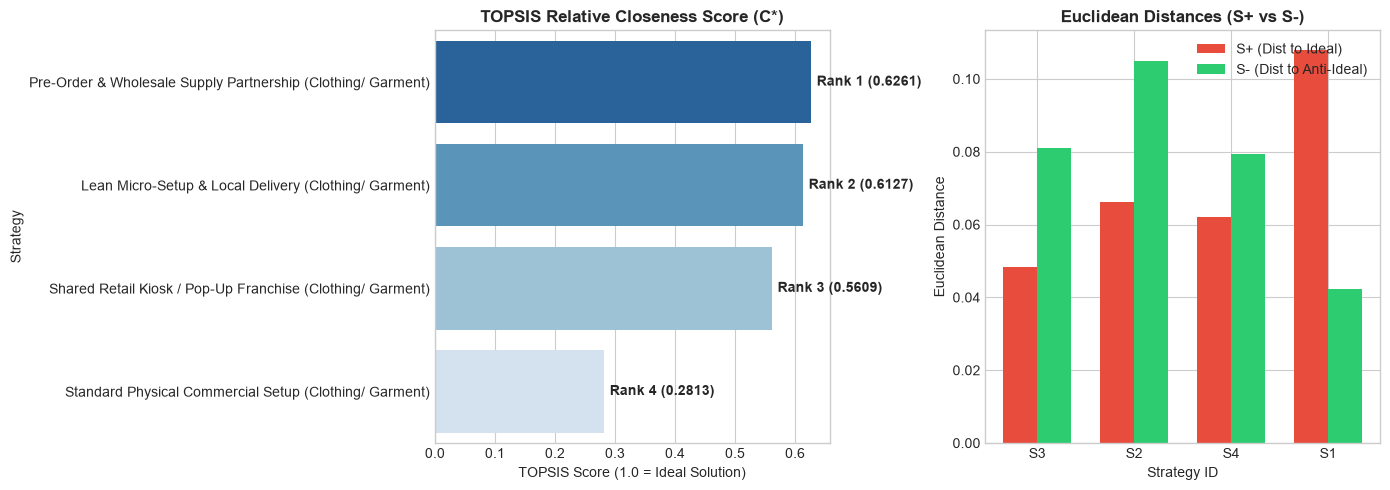

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: TOPSIS Score Bar Chart
sns.barplot(
    data=ranked_df,
    x="TOPSIS_Score",
    y="title",
    palette="Blues_r",
    ax=ax1
)
ax1.set_title("TOPSIS Relative Closeness Score (C*)", fontsize=12, fontweight='bold')
ax1.set_xlabel("TOPSIS Score (1.0 = Ideal Solution)")
ax1.set_ylabel("Strategy")
for i, v in enumerate(ranked_df["TOPSIS_Score"]):
    ax1.text(v + 0.01, i, f"Rank {ranked_df['Rank'].iloc[i]} ({v:.4f})", va='center', fontweight='bold')

# Plot 2: Distance to Ideal (S+) vs Distance to Anti-Ideal (S-)
x_pos = np.arange(len(ranked_df))
width = 0.35

ax2.bar(x_pos - width/2, ranked_df["S_plus"], width, label="S+ (Dist to Ideal)", color="#e74c3c")
ax2.bar(x_pos + width/2, ranked_df["S_minus"], width, label="S- (Dist to Anti-Ideal)", color="#2ecc71")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(ranked_df["strategy_id"])
ax2.set_title("Euclidean Distances (S+ vs S-)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Strategy ID")
ax2.set_ylabel("Euclidean Distance")
ax2.legend()

plt.tight_layout()
plt.savefig("../reports/figures/07_topsis_scores.png", dpi=300, bbox_inches='tight')
plt.show()


## 5. Weight Sensitivity Analysis
To test the stability of TOPSIS strategy rankings, we evaluate decision rankings across 3 distinct stakeholder preference profiles:
1. **Balanced Weights**: Standard distribution.
2. **Capital-Preserving (Risk-Averse)**: High weight on `initial_investment_lkr` and `monthly_operating_cost_lkr`.
3. **Revenue-Maximizing (Aggressive Growth)**: High weight on `expected_monthly_revenue_lkr` and `market_demand_score`.


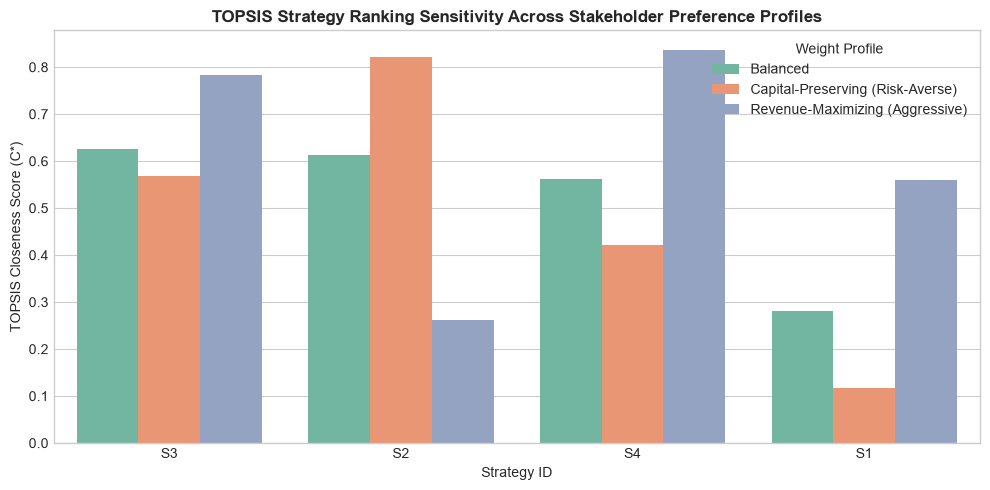

Sensitivity Rank Matrix:


Weight Profile,Balanced,Capital-Preserving (Risk-Averse),Revenue-Maximizing (Aggressive)
Strategy ID,,,
S1,4,4,3
S2,2,1,4
S3,1,2,2
S4,3,3,1


In [6]:
weight_profiles = {
    "Balanced": {
        "initial_investment_lkr": 0.20, "monthly_operating_cost_lkr": 0.15,
        "expected_monthly_revenue_lkr": 0.20, "market_demand_score": 0.15,
        "competition_mitigation_score": 0.10, "resource_availability_score": 0.05,
        "location_suitability_score": 0.05, "implementation_difficulty": 0.10
    },
    "Capital-Preserving (Risk-Averse)": {
        "initial_investment_lkr": 0.35, "monthly_operating_cost_lkr": 0.25,
        "expected_monthly_revenue_lkr": 0.10, "market_demand_score": 0.10,
        "competition_mitigation_score": 0.05, "resource_availability_score": 0.05,
        "location_suitability_score": 0.05, "implementation_difficulty": 0.05
    },
    "Revenue-Maximizing (Aggressive)": {
        "initial_investment_lkr": 0.05, "monthly_operating_cost_lkr": 0.05,
        "expected_monthly_revenue_lkr": 0.40, "market_demand_score": 0.25,
        "competition_mitigation_score": 0.10, "resource_availability_score": 0.05,
        "location_suitability_score": 0.05, "implementation_difficulty": 0.05
    }
}

sensitivity_records = []

for prof_name, w_dict in weight_profiles.items():
    r_df, _, _, _ = top_ranker.rank_strategies(candidate_list, weights=w_dict)
    for _, row in r_df.iterrows():
        sensitivity_records.append({
            "Weight Profile": prof_name,
            "Strategy ID": row["strategy_id"],
            "Title": row["title"],
            "TOPSIS Score": row["TOPSIS_Score"],
            "Rank": row["Rank"]
        })

sens_df = pd.DataFrame(sensitivity_records)

# Plot Sensitivity Comparison
plt.figure(figsize=(10, 5))
sns.barplot(
    data=sens_df,
    x="Strategy ID",
    y="TOPSIS Score",
    hue="Weight Profile",
    palette="Set2"
)
plt.title("TOPSIS Strategy Ranking Sensitivity Across Stakeholder Preference Profiles", fontsize=12, fontweight='bold')
plt.xlabel("Strategy ID")
plt.ylabel("TOPSIS Closeness Score (C*)")
plt.legend(title="Weight Profile")
plt.tight_layout()
plt.savefig("../reports/figures/07_topsis_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()

print("Sensitivity Rank Matrix:")
sens_pivot = sens_df.pivot(index="Strategy ID", columns="Weight Profile", values="Rank")
sens_pivot


## 6. Export TOPSIS Ranked Strategy Artifacts
Saving ranked strategy payload to `models/feasibility_model/topsis_ranked_strategies.json` for Phase 8 (What-If Engine) & Phase 9 (Personalized Business Plan Generator).


In [7]:
topsis_export = {
    "case_id": sample_scenario["case_id"],
    "input_profile": sample_scenario["input_profile"],
    "prediction": sample_scenario["prediction"],
    "top_ranked_strategy": ranked_df.iloc[0].to_dict(),
    "all_ranked_strategies": ranked_df.to_dict(orient="records"),
    "sensitivity_results": sens_df.to_dict(orient="records")
}

export_path = "../models/feasibility_model/topsis_ranked_strategies.json"
with open(export_path, "w", encoding="utf-8") as f:
    json.dump(topsis_export, f, indent=4)

print(f"Successfully exported TOPSIS Ranked Strategy Artifacts to '{export_path}'")


Successfully exported TOPSIS Ranked Strategy Artifacts to '../models/feasibility_model/topsis_ranked_strategies.json'
